# Setup / Load Results

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]  # adjust if notebook is nested
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [2]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"
print(env_file.exists())
load_dotenv(env_file)
print("Loaded env file:", env_file)

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env


In [3]:
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

benchmarkdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
benchmarkdb_config_dict = load_config(benchmarkdb_config_file_path)

logger = get_logger("benchmark_db", benchmarkdb_config_dict["general"]["log_file"])
benchmarkdb_config = get_postgres_config(benchmarkdb_config_dict["database"])
benchmarkdb_repo = BenchmarkDB(benchmarkdb_config, logger)

try:
    benchmarkdb_repo.connect()
    print("Connected to BenchmarkDB successfully.")
except Exception as e:
    print("Failed to connect to BenchmarkDB:", e)

Connected to BenchmarkDB successfully.


In [4]:
disk_ALL = benchmarkdb_repo.get_all_disk_size_benchmark_results()
len(disk_ALL)

51

In [5]:
one_r = disk_ALL[0]
print(one_r)

DiskSizeBenchmarkResult 1
  benchmark:           disk_size.per_batch_delta
  database system:     influxdb
  database version:    2.7
  batch id:            0
  dataset:             baseline_empty
  record count:        0
  cumulative records:  0
  size before:         204,800 bytes
  size after:          204,800 bytes
  size delta:          0 bytes
  created at:          2026-08-14T12:32:57.284202+00:00


# Partition

In [6]:
from collections import defaultdict

db_results = defaultdict(list)
for r in disk_ALL:
    db_results[r.database_system].append(r)

db_systems = sorted(db_results.keys())
db_systems

['influxdb', 'mongodb', 'timescaledb']

In [7]:
DB_COLOR_MAP = {
    'mongodb':     '#00ED64',
    'influxdb':    '#F18F13',
    'timescaledb': '#0064FF',
    'questdb':     '#FF5733',
}
DB_COLORS = ['#00ED64', '#F18F13', '#0064FF', '#FF5733', '#A855F7', '#EC4899']

db_color = {
    db: DB_COLOR_MAP.get(db, DB_COLORS[i % len(DB_COLORS)])
    for i, db in enumerate(db_systems)
}
db_color

{'influxdb': '#F18F13', 'mongodb': '#00ED64', 'timescaledb': '#0064FF'}

# Analysis

In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Delta per Batch — Per Database

One figure per database, x-axis is batch (by record count), y-axis is delta bytes for just that batch's insert.

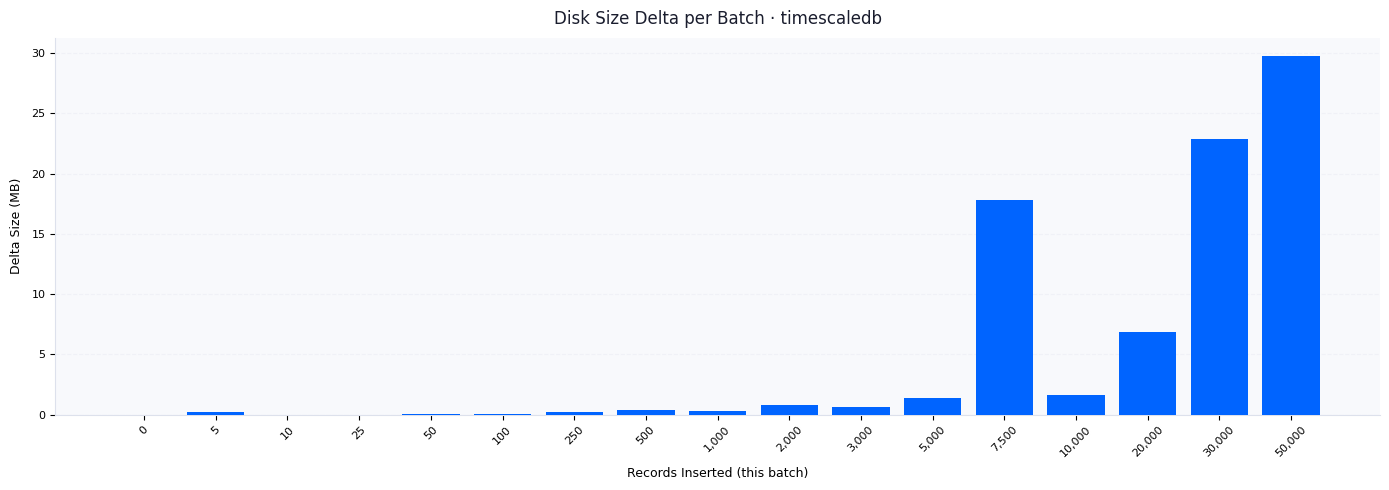

In [9]:
database = "timescaledb" 

results_db = sorted(
    db_results[database],
    key=lambda r: r.cumulative_record_count,
)

x_labels = [f'{r.record_count:,}' for r in results_db]
y_delta_mb = [r.disk_size_delta_bytes / (1024 * 1024) for r in results_db]
color = db_color[database]

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

ax.bar(x_labels, y_delta_mb, color=color, zorder=3)

ax.set_title(f'Disk Size Delta per Batch · {database}', fontsize=12, pad=10, color='#1a1d2e')
ax.set_xlabel('Records Inserted (this batch)', fontsize=9, labelpad=6)
ax.set_ylabel('Delta Size (MB)', fontsize=9, labelpad=6)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Delta per Batch — All Databases, Grouped Bars

The main comparison chart: one group per batch, one bar per database, showing marginal disk cost of each dataset size side by side.

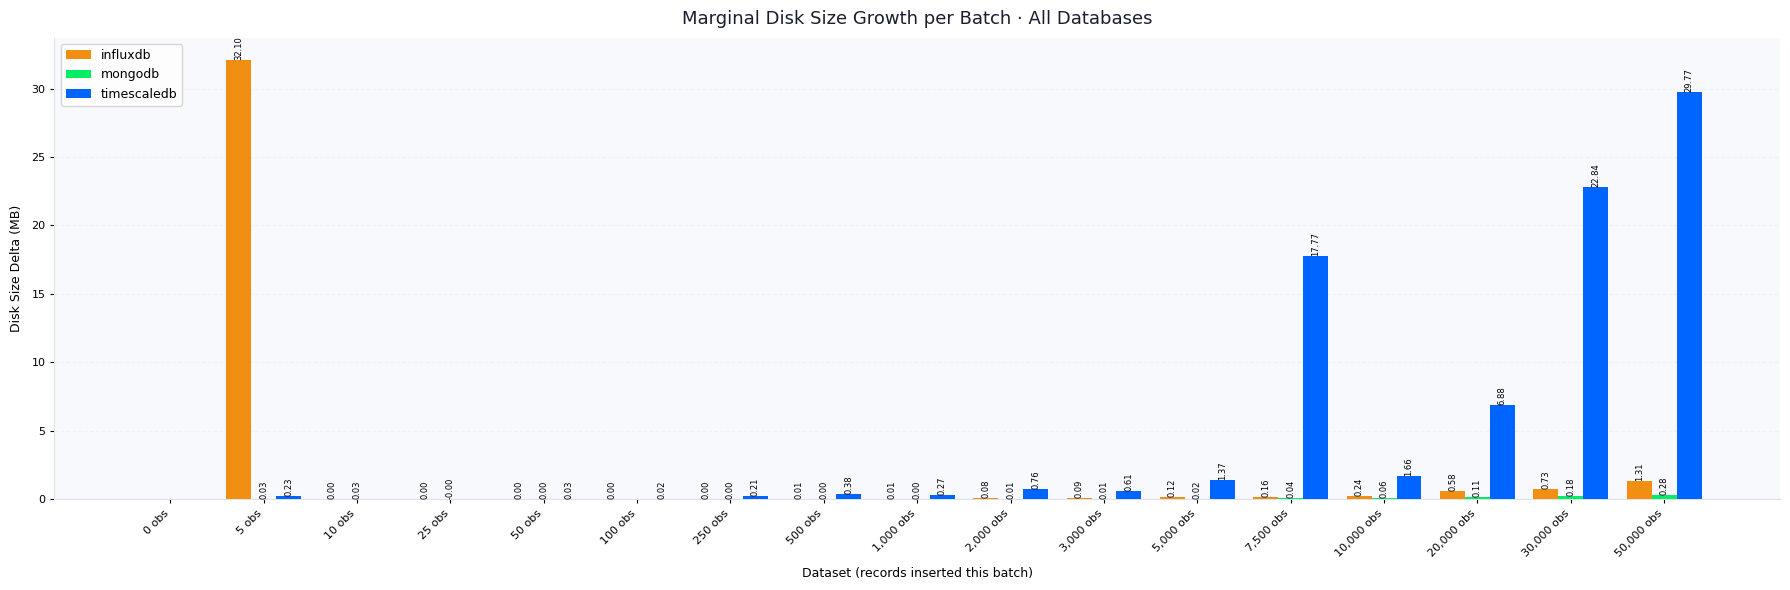

In [10]:
list_of_batch_ids = sorted({r.batch_id for db in db_systems for r in db_results[db]})

x = np.arange(len(list_of_batch_ids))
n_dbs = len(db_systems)
bar_width = 0.8 / n_dbs
x_labels = []

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for i, db in enumerate(db_systems):
    deltas_mb = []
    for batch_id in list_of_batch_ids:
        match = [r for r in db_results[db] if r.batch_id == batch_id]
        deltas_mb.append(match[0].disk_size_delta_bytes / (1024 * 1024) if match else 0)

    offsets = x + i * bar_width - (n_dbs - 1) * bar_width / 2
    bars = ax.bar(offsets, deltas_mb, width=bar_width, color=db_color[db], label=db, zorder=3)

    for bar, val in zip(bars, deltas_mb):
        if val != 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:,.2f}', ha='center', va='bottom', fontsize=6, rotation=90)

for batch_id in list_of_batch_ids:
    first_r = next(r for db in db_systems for r in db_results[db] if r.batch_id == batch_id)
    x_labels.append(f'{first_r.record_count:,} obs')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha='right')
ax.set_xlabel('Dataset (records inserted this batch)', fontsize=9, labelpad=6)
ax.set_ylabel('Disk Size Delta (MB)', fontsize=9, labelpad=6)
ax.set_title('Marginal Disk Size Growth per Batch · All Databases', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='both', length=3, labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Delta per Batch — Separate Figure per Dataset

One figure per batch (dataset size), each showing the delta bytes for that single insert across all databases side by side. This isolates each dataset size into its own chart instead of cramming all 16 onto one x-axis.

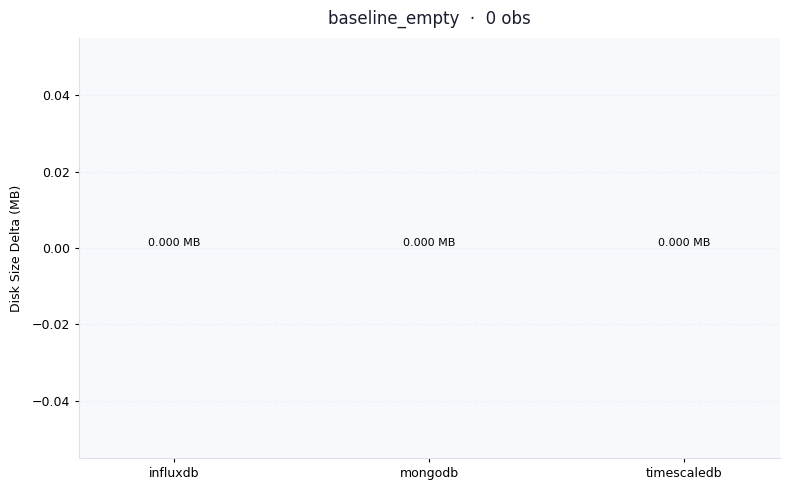

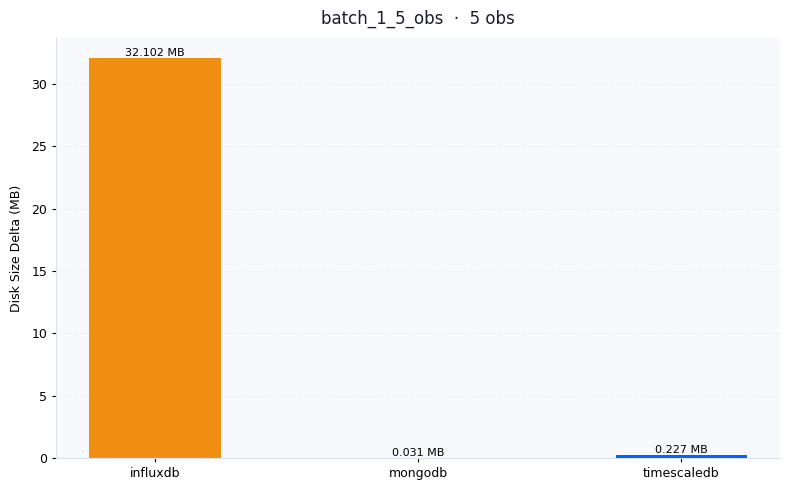

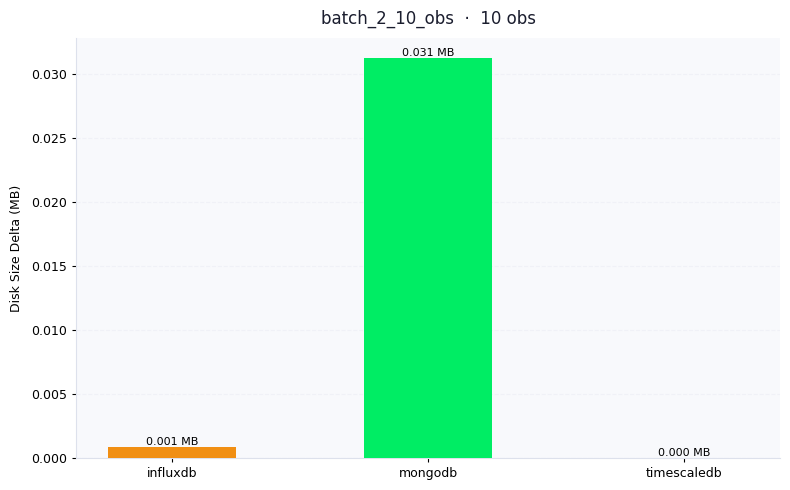

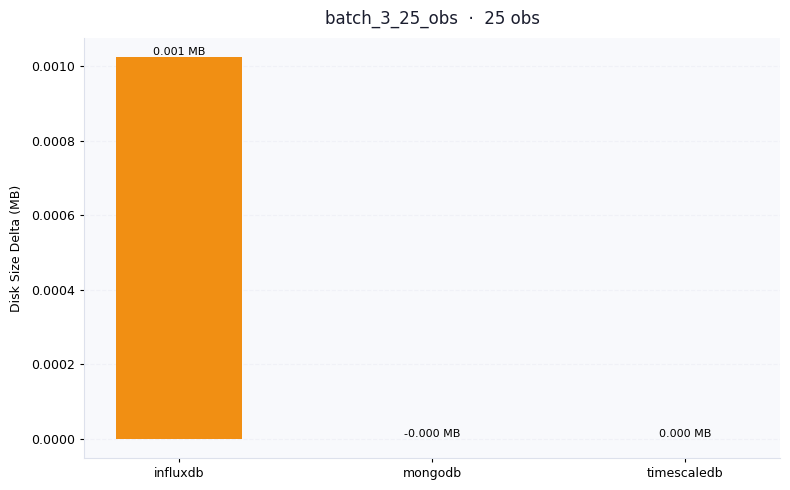

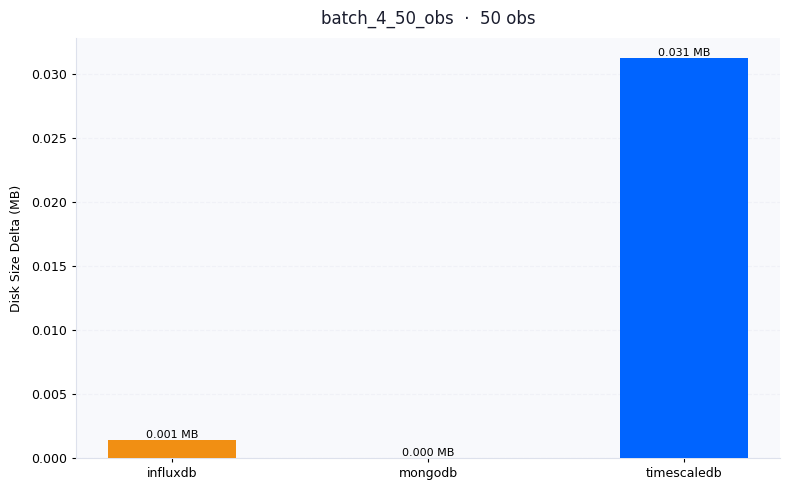

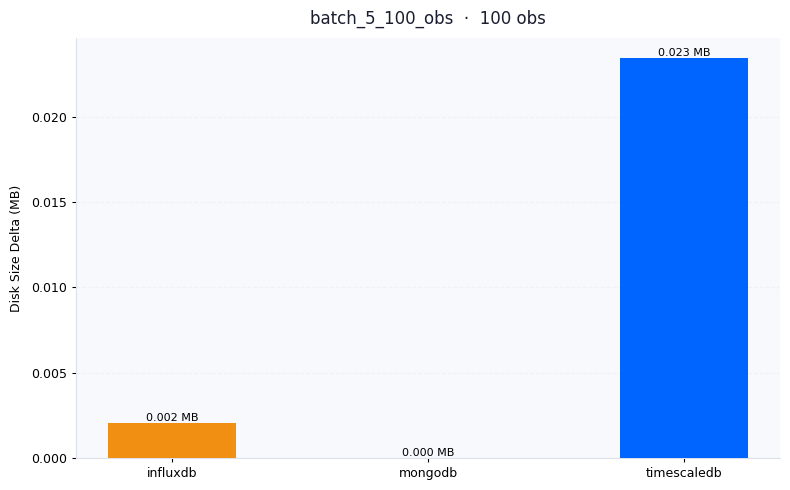

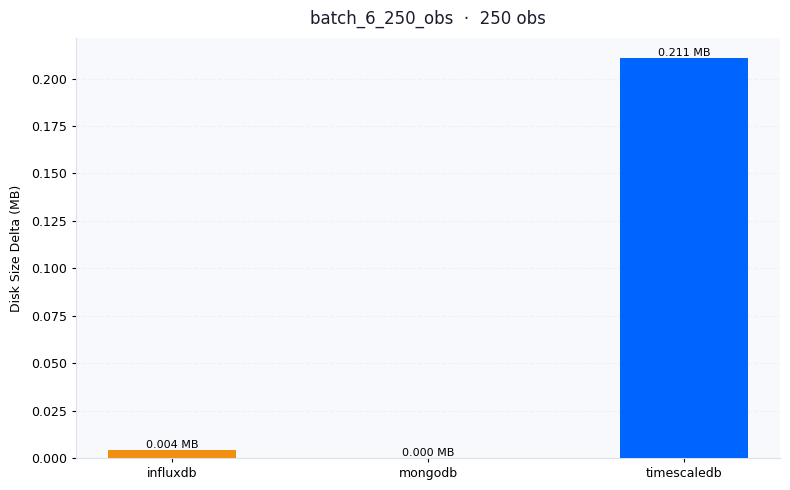

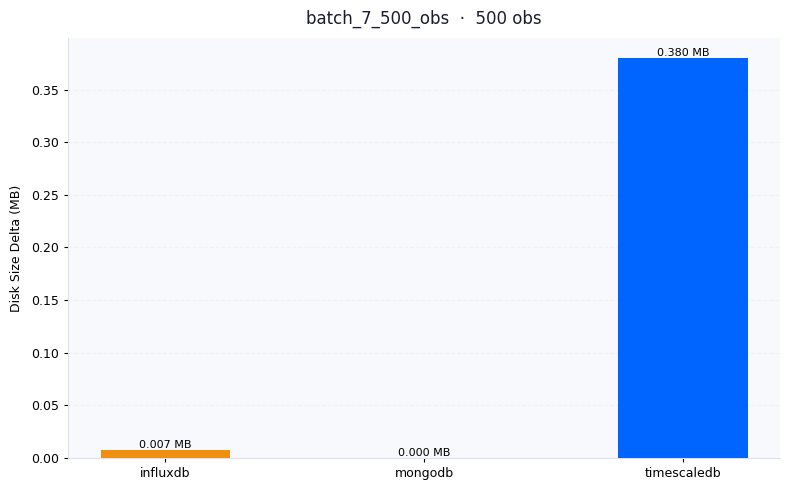

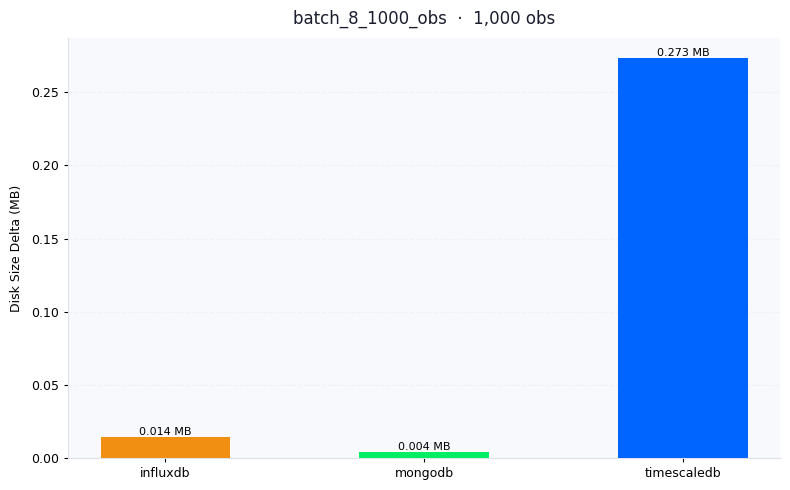

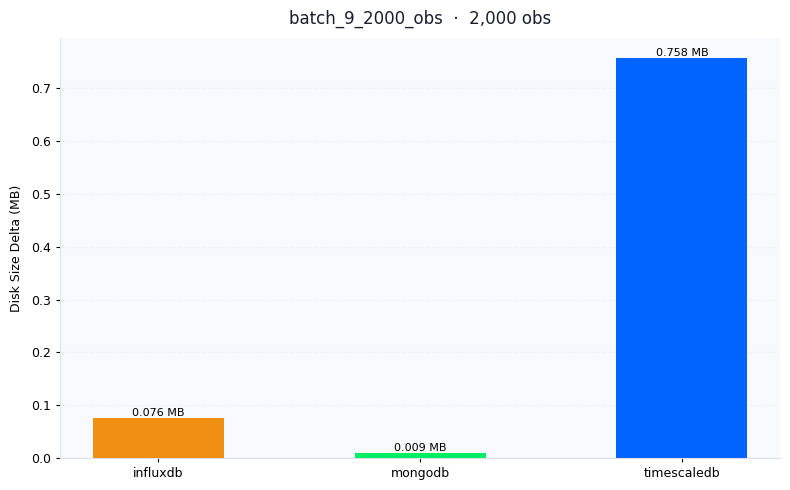

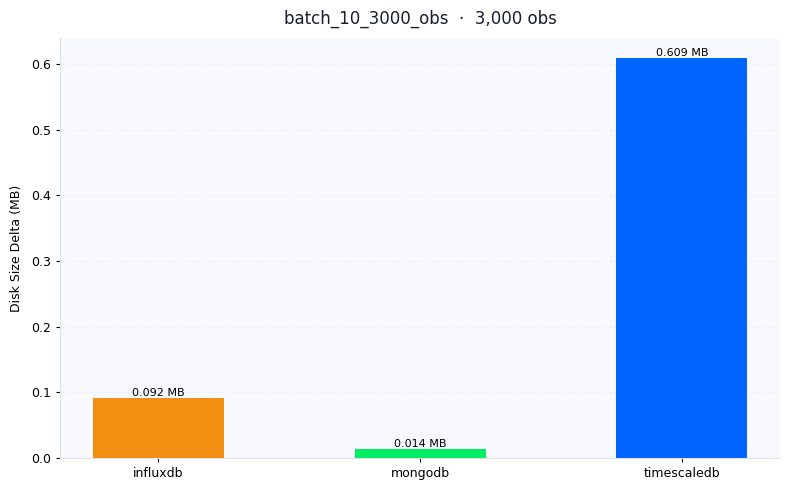

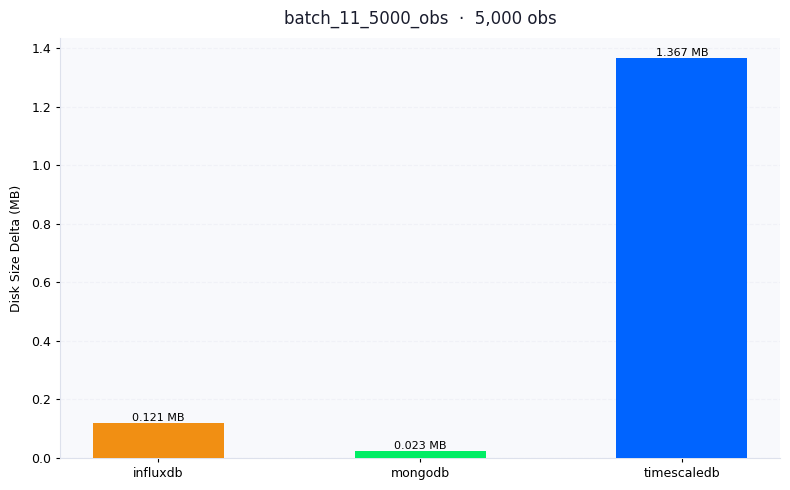

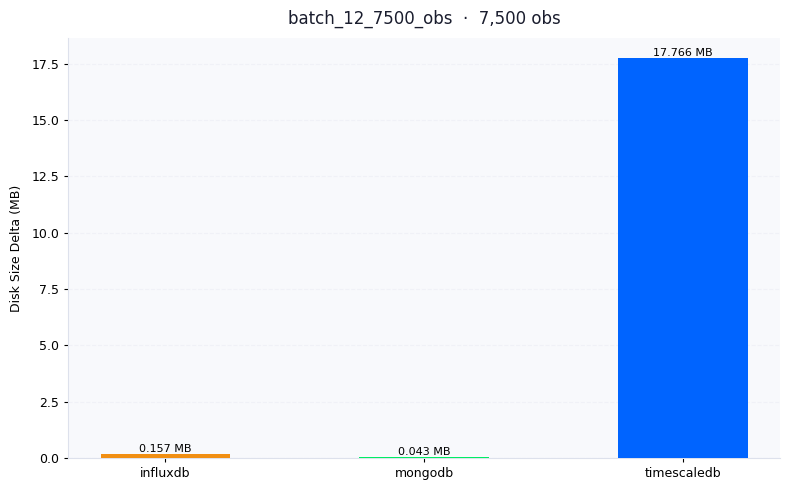

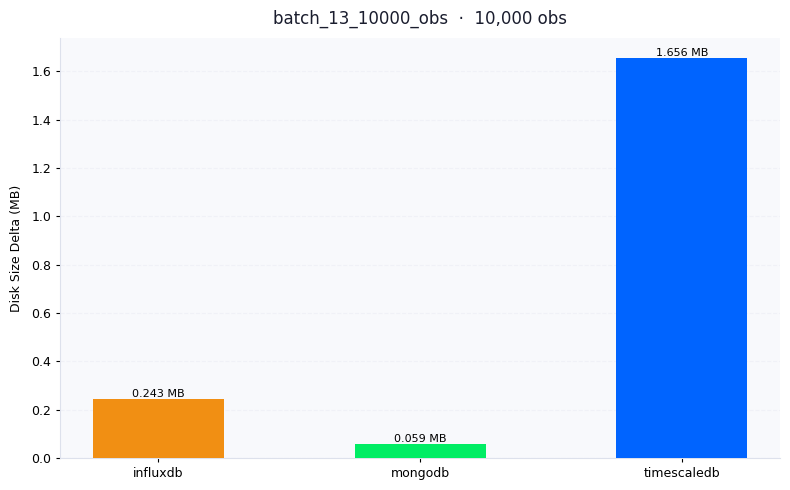

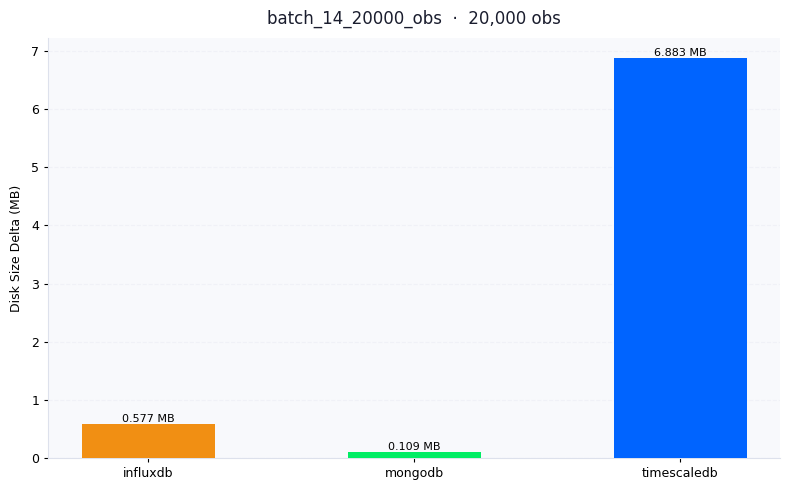

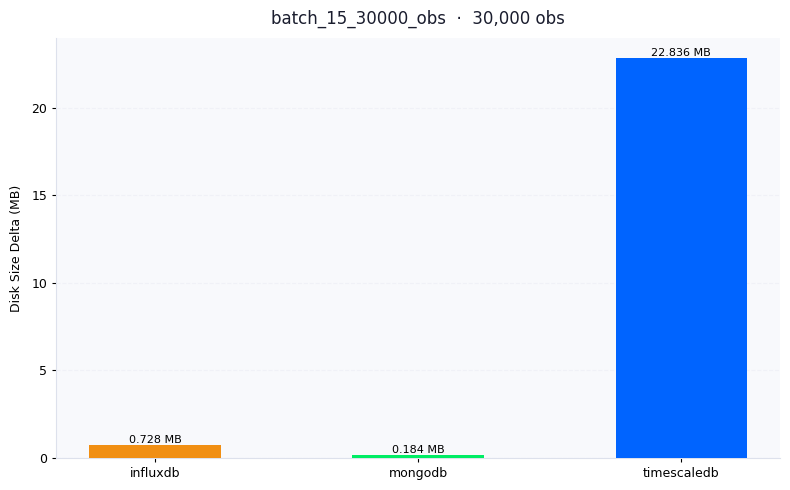

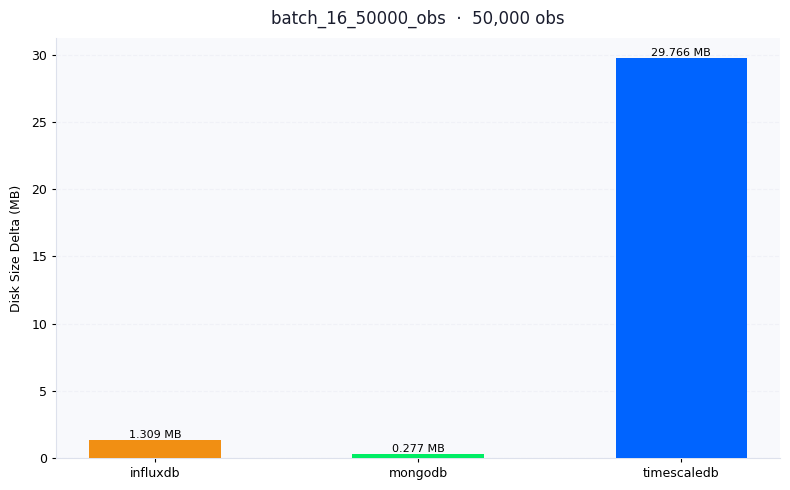

In [11]:
list_of_batch_ids = sorted({r.batch_id for db in db_systems for r in db_results[db]})

for batch_id in list_of_batch_ids:
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#f8f9fc')

    dbs_with_data = []
    deltas_mb = []
    colors = []

    for db in db_systems:
        match = [r for r in db_results[db] if r.batch_id == batch_id]
        if match:
            dbs_with_data.append(db)
            deltas_mb.append(match[0].disk_size_delta_bytes / (1024 * 1024))
            colors.append(db_color[db])

    if not dbs_with_data:
        plt.close(fig)
        continue

    bars = ax.bar(dbs_with_data, deltas_mb, color=colors, zorder=3, width=0.5)

    for bar, val in zip(bars, deltas_mb):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,.3f} MB', ha='center', va='bottom', fontsize=8)

    first_r = next(r for db in db_systems for r in db_results[db] if r.batch_id == batch_id)

    ax.set_title(
        f'{first_r.dataset_name}  ·  {first_r.record_count:,} obs',
        fontsize=12, pad=10, color='#1a1d2e',
    )
    ax.set_ylabel('Disk Size Delta (MB)', fontsize=9, labelpad=6)
    ax.tick_params(axis='both', length=3, labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#dde1ec')
    ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

    plt.tight_layout()
    plt.show()

# Delta per Record (Normalized) — All Databases

Since batch sizes vary a lot (5 obs vs 50,000 obs), raw delta bars aren't directly comparable across batches. This normalizes to bytes consumed per record in that batch — the more meaningful efficiency metric.

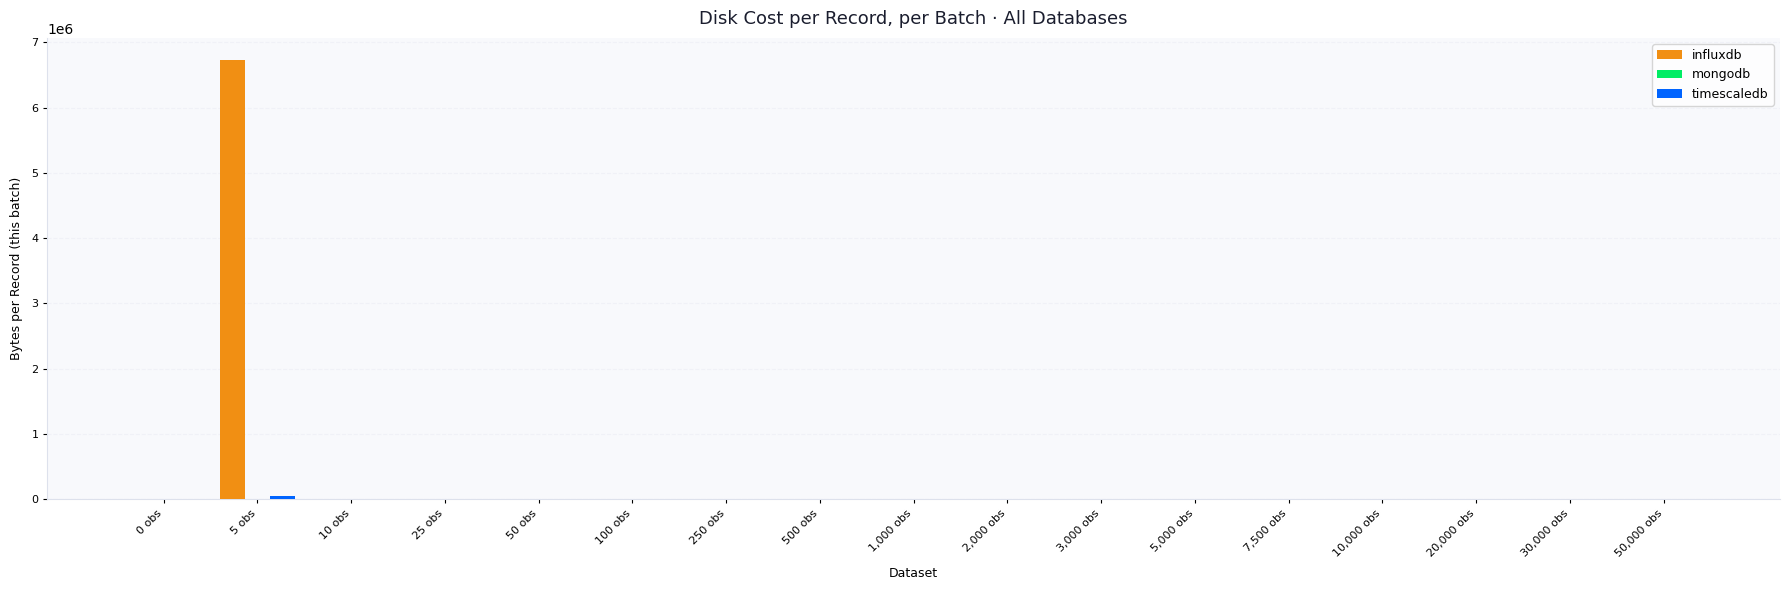

In [12]:
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for i, db in enumerate(db_systems):
    per_record = []
    for batch_id in list_of_batch_ids:
        match = [r for r in db_results[db] if r.batch_id == batch_id]
        if match and match[0].record_count > 0:
            per_record.append(match[0].disk_size_delta_bytes / match[0].record_count)
        else:
            per_record.append(0)

    offsets = x + i * bar_width - (n_dbs - 1) * bar_width / 2
    ax.bar(offsets, per_record, width=bar_width, color=db_color[db], label=db, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha='right')
ax.set_xlabel('Dataset', fontsize=9, labelpad=6)
ax.set_ylabel('Bytes per Record (this batch)', fontsize=9, labelpad=6)
ax.set_title('Disk Cost per Record, per Batch · All Databases', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='both', length=3, labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Bytes per Record — Single Batch, Selectable by Index

Same normalized bytes-per-record view, but scoped to one dataset/batch at a time, chosen by index into list_of_batch_ids. This lets you skip past the first batch (which carries page-allocation overhead, as we saw earlier) by just changing BATCH_INDEX.

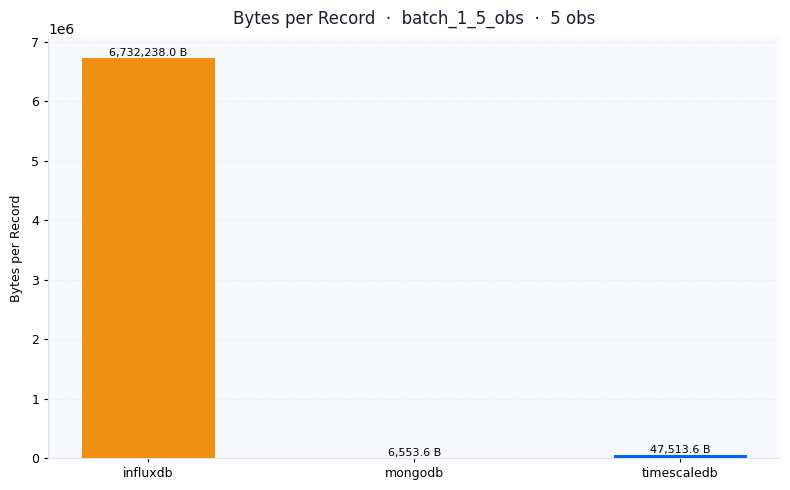

In [13]:
list_of_batch_ids = sorted({r.batch_id for db in db_systems for r in db_results[db]})

# Change this to pick which dataset/batch to plot.
# 0 = first batch (batch_1, smallest — has allocation overhead)
# 1 = second batch, etc.
BATCH_INDEX = 1

batch_id = list_of_batch_ids[BATCH_INDEX]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

dbs_with_data = []
per_record = []
colors = []

for db in db_systems:
    match = [r for r in db_results[db] if r.batch_id == batch_id]
    if match and match[0].record_count > 0:
        dbs_with_data.append(db)
        per_record.append(match[0].disk_size_delta_bytes / match[0].record_count)
        colors.append(db_color[db])

bars = ax.bar(dbs_with_data, per_record, color=colors, zorder=3, width=0.5)

for bar, val in zip(bars, per_record):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:,.1f} B', ha='center', va='bottom', fontsize=8)

first_r = next(r for db in db_systems for r in db_results[db] if r.batch_id == batch_id)

ax.set_title(
    f'Bytes per Record  ·  {first_r.dataset_name}  ·  {first_r.record_count:,} obs',
    fontsize=12, pad=10, color='#1a1d2e',
)
ax.set_ylabel('Bytes per Record', fontsize=9, labelpad=6)
ax.tick_params(axis='both', length=3, labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Bytes per Record, per Batch — All Databases, From a Chosen Starting Index

Same grouped-bar comparison as the full version, but the x-axis starts at START_INDEX into list_of_batch_ids, letting you exclude the first batch(es) where page-allocation overhead skews the per-record cost.

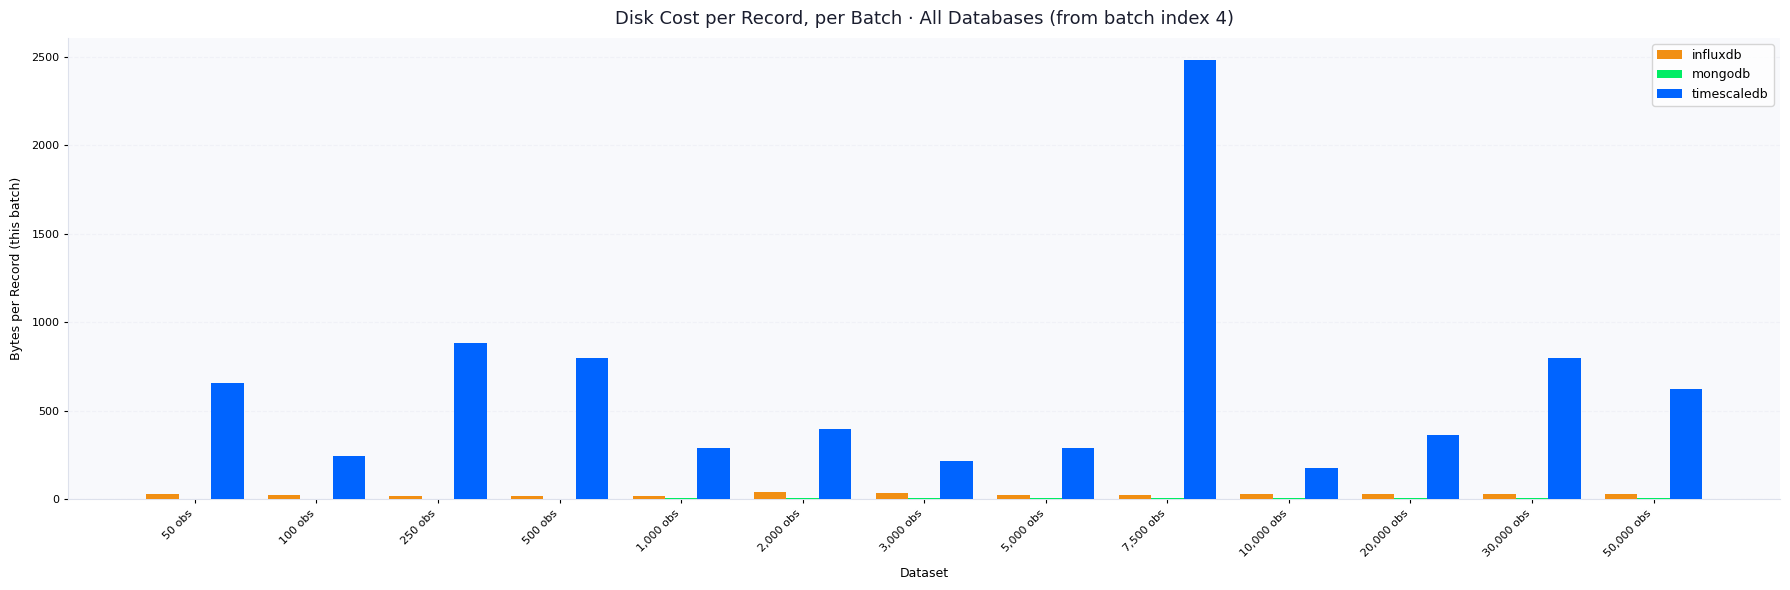

In [14]:
list_of_batch_ids = sorted({r.batch_id for db in db_systems for r in db_results[db]})

# Change this to skip the first N batches (e.g. 1 to skip batch_1, which has allocation overhead)
START_INDEX = 4

batch_ids_subset = list_of_batch_ids[START_INDEX:]

x = np.arange(len(batch_ids_subset))
n_dbs = len(db_systems)
bar_width = 0.8 / n_dbs
x_labels = []

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for i, db in enumerate(db_systems):
    per_record = []
    for batch_id in batch_ids_subset:
        match = [r for r in db_results[db] if r.batch_id == batch_id]
        if match and match[0].record_count > 0:
            per_record.append(match[0].disk_size_delta_bytes / match[0].record_count)
        else:
            per_record.append(0)

    offsets = x + i * bar_width - (n_dbs - 1) * bar_width / 2
    ax.bar(offsets, per_record, width=bar_width, color=db_color[db], label=db, zorder=3)

for batch_id in batch_ids_subset:
    first_r = next(r for db in db_systems for r in db_results[db] if r.batch_id == batch_id)
    x_labels.append(f'{first_r.record_count:,} obs')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha='right')
ax.set_xlabel('Dataset', fontsize=9, labelpad=6)
ax.set_ylabel('Bytes per Record (this batch)', fontsize=9, labelpad=6)
ax.set_title(
    f'Disk Cost per Record, per Batch · All Databases (from batch index {START_INDEX})',
    fontsize=13, pad=10, color='#1a1d2e',
)
ax.tick_params(axis='both', length=3, labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Summary Table

In [15]:
rows = []
for db in db_systems:
    deltas = [r.disk_size_delta_bytes for r in db_results[db]]
    records = [r.record_count for r in db_results[db]]
    total_delta = sum(deltas)
    total_records = sum(records)

    rows.append({
        'database_system':      db,
        'n_batches':             len(db_results[db]),
        'total_delta_mb':        round(total_delta / (1024*1024), 2),
        'total_records':         total_records,
        'avg_bytes_per_record':  round(total_delta / total_records, 2) if total_records else 0,
        'min_delta_mb':          round(min(deltas) / (1024*1024), 4),
        'max_delta_mb':          round(max(deltas) / (1024*1024), 4),
    })

summary_df = pd.DataFrame(rows).set_index('database_system')
summary_df

,n_batches,total_delta_mb,total_records,avg_bytes_per_record,min_delta_mb,max_delta_mb
database_system,,,,,,
influxdb,17,35.44,129440,287.06,0.0,32.1018
mongodb,17,0.78,129440,6.35,-0.0,0.2773
timescaledb,17,82.79,129440,670.64,0.0,29.7656
